In [1]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd 
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import sys

plt.rcParams['svg.fonttype'] = 'none'
sys.path.append("../src")
from evaluation_metrics import *
from utils_evaluation import *

In [2]:
results = "../evaluation_results/1_4_edist/*.csv"

In [3]:
csvs = glob(results)

In [4]:
datasets = [f"mcfarland_{i}" for i in range(1, 6)] + ["bhattacherjee_Astro", "bhattacherjee_Endo", "bhattacherjee_Excitatory", "norman", "schiebinger"]

In [5]:
dfs = list()
runtime_memory = list()
for dataset in datasets:
    dataset_df_dict = {os.path.basename(csv).split("_")[0]: pd.read_csv(csv, index_col="testgroup") for csv in csvs if dataset in csv}
    for method in dataset_df_dict:
        dataset_df_dict[method].columns = [f"{method}_{c}" for c in dataset_df_dict[method].columns]
    dataset_df = pd.concat(list(dataset_df_dict.values()), axis=1)
    dataset_df["xm_perturbation_strength"] /= np.max(dataset_df["xm_perturbation_strength"])
    dataset_df["dataset"] = dataset
    dataset_df["xm_P_adj"] = multipletests(dataset_df["xm_P"], method="fdr_bh")[1]
    dfs.append(dataset_df)
result = pd.concat(dfs)

In [6]:
result["log1p(xm_P_adj)"] = np.log1p(result["xm_P_adj"])
result["log1p(edist_P_adj)"] = np.log1p(result["edist_P_adj"])

In [7]:
np.log10(1)

0.0

In [8]:
result

,edist_reference,edist_relative_support,edist_time_pca,edist_time_edist_test,edist_P,edist_P_adj,edist_total_RAM,xm_reference,xm_relative_support,xm_time_test,xm_P,xm_total_RAM,xm_perturbation_strength,dataset,xm_P_adj,log1p(xm_P_adj),log1p(edist_P_adj)
testgroup,,,,,,,,,,,,,,,,,
Idasanutlin_24,control,0.909747,0.666913,20.516501,0.0001,0.000300,1.3,control,1.000000,6.987921,5.873726e-11,0.4,1.000000,mcfarland_1,5.873726e-11,5.873726e-11,0.000300
Idasanutlin_6,control,1.000000,0.666913,20.516501,0.0001,0.000300,1.3,control,0.998930,0.664136,2.610203e-32,0.4,0.500000,mcfarland_1,5.220407e-32,5.220407e-32,0.000300
Trametinib_24,control,0.643917,0.352241,19.507984,0.0001,0.000300,1.2,control,1.000000,6.163425,1.787834e-79,0.3,1.000000,mcfarland_2,3.575669e-79,3.575669e-79,0.000300
Trametinib_6,control,1.000000,0.352241,19.507984,0.0001,0.000300,1.2,control,1.000000,0.599848,1.295669e-44,0.3,0.500000,mcfarland_2,1.295669e-44,1.295669e-44,0.000300
BRD3379_24,control,0.692547,0.359998,19.780210,0.0001,0.000300,0.7,control,0.998636,6.039345,7.100694e-69,0.0,1.000000,mcfarland_3,1.420139e-68,1.420139e-68,0.000300
BRD3379_6,control,1.000000,0.359998,19.780210,0.0001,0.000300,0.7,control,0.996845,0.444491,9.387059e-16,0.0,0.500000,mcfarland_3,9.387059e-16,9.387059e-16,0.000300
BRD3379_24,control,0.751825,1.123142,18.485438,0.0001,0.000300,1.1,control,0.998632,5.719239,1.039068e-45,0.4,1.000000,mcfarland_4,2.078136e-45,2.078136e-45,0.000300
BRD3379_6,control,1.000000,1.123142,18.485438,0.0001,0.000300,1.1,control,0.998492,0.456138,9.700820e-20,0.4,0.500000,mcfarland_4,9.700820e-20,9.700820e-20,0.000300
BRD3379_24,control,0.679054,0.358430,18.154876,0.0001,0.000300,0.8,control,1.000000,5.472059,4.254369e-40,0.0,1.000000,mcfarland_5,8.508737e-40,8.508737e-40,0.000300


In [9]:
pal = sns.color_palette("YlOrBr", as_cmap=True)

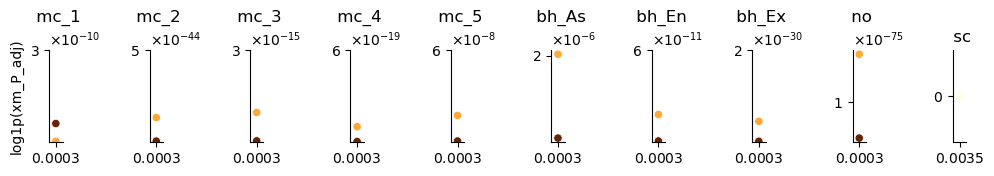

In [10]:
f = sns.relplot(result.sort_values("xm_perturbation_strength", ascending=False), col="dataset", x="log1p(edist_P_adj)", y="log1p(xm_P_adj)", facet_kws={"sharex":False, "sharey":False}, hue="xm_perturbation_strength", height=2, aspect=0.5, marker="o", legend=False, sizes=(10,200), palette=pal, col_order=result["dataset"].unique())
for ax in f.axes.flat:
    splits = ax.get_title().split("=")[1].split("_")
    if len(splits) > 1:
        title = f"{splits[0][:3]}_{splits[1][:2]}"
    else:
        title = splits[0][:3]
    ax.set_title(title)
    ax.ticklabel_format(useMathText=True)
    val = np.mean(ax.get_yticks())
    if val != 0:
        ax.set_yticks([int(np.ceil(float(str(val).split("e")[0]))) * 10 **int(np.log10(val))])
    else:
        ax.set_yticks([0])

    ax.set_xticks([np.mean(ax.get_xticks())])
    ax.set_xlabel(None)
plt.savefig("../plots/fig3/fig3_edist_P-values.svg", bbox_inches="tight")

In [11]:
val = np.mean(ax.get_yticks())
#val *= 10**(-np.log10(val))
#val

In [12]:
np.log10(val)

/tmp/ipykernel_4068398/2740058511.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(val)


-inf

In [13]:
pal = {f"mcfarland_{i}": sns.color_palette("Blues", 5)[i-1] for i in range(1, 6)}
pal.update({"bhattacherjee_Astro": sns.color_palette("Greens", 3)[0], "bhattacherjee_Endo": sns.color_palette("Reds", 3)[1], "bhattacherjee_Excitatory": sns.color_palette("Reds", 3)[2],})
pal.update({"norman": sns.color_palette("Purples", 1)[0]})
pal.update({"schiebinger": sns.color_palette("Greys", 1)[0]})

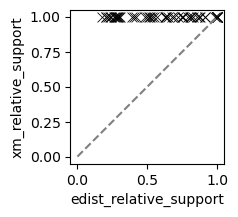

In [14]:
plt.figure(figsize=(2,2))
sns.scatterplot(result.sort_values("dataset", ascending=False), x="edist_relative_support", y="xm_relative_support", s=50, alpha=1, legend=False, marker="x", color="black")
plt.plot([0, 1], [0, 1], ls="--", color="grey")
plt.axis("square")
plt.savefig("../plots/fig3/fig3_edist_support.svg", bbox_inches="tight")

In [15]:
ram_edist = result[["dataset", "edist_total_RAM"]].drop_duplicates().reset_index(drop=True).set_index("dataset")
ram_xm = result[["dataset", "xm_total_RAM"]].drop_duplicates().reset_index(drop=True).set_index("dataset")
ram = pd.concat([ram_edist, ram_xm], axis=1).reset_index(names="dataset")

/tmp/ipykernel_4068398/3814873161.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(ram, x="edist_total_RAM", y="xm_total_RAM", s=100, legend=False, palette=pal, marker="x", color="black")


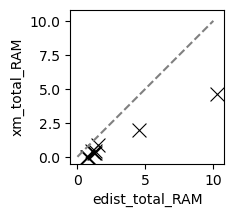

In [16]:
plt.figure(figsize=(2,2))
sns.scatterplot(ram, x="edist_total_RAM", y="xm_total_RAM", s=100, legend=False, palette=pal, marker="x", color="black")
plt.plot([0, 10], [0, 10], ls="--", color="grey")
plt.axis("square")
plt.savefig("../plots/fig3/fig3_edist_RAM.svg", bbox_inches="tight")

In [17]:
xm_time = dict()
edist_time = dict()
for (dataset, df) in result.groupby("dataset"):
    xm_time[dataset] = df["xm_time_test"].sum()
    edist_time[dataset] = df["edist_time_pca"].iloc[0] + df["edist_time_edist_test"].iloc[0]

In [18]:
times = pd.DataFrame([xm_time, edist_time], index=["scXMatch", "E-distance"]).T.reset_index(names="dataset")

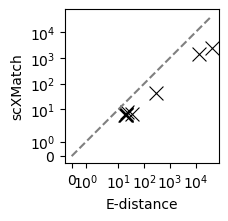

In [19]:
plt.figure(figsize=(2,2))
sns.scatterplot(times, x="E-distance", y="scXMatch", s=100, legend=False, marker="x", color="black")
max_val = np.max(times[["scXMatch", "E-distance"]].values)
plt.plot([0, max_val], [0, max_val], ls="--", color="grey")
plt.yscale("symlog")
plt.xscale("symlog")
plt.axis("square")
plt.savefig("../plots/fig3/fig3_edist_time.svg", bbox_inches="tight")